In [ ]:
import importlib.util
import sys
from datetime import date
import pandas as pd
import numpy as np
from typing import Dict, Literal, Optional
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import os
from pathlib import Path
from src.dataloading import EpiDataLoader

wissdaten_dir    = os.environ.get('TMPDIR') +'/wissdaten/'
data_env         = os.path.join(wissdaten_dir, 'ZKI-PH4/deschrijvers_wissdaten/data')

data_module      = module_path = data_env + "/__init__.py"
spec = importlib.util.spec_from_file_location("data", module_path)
module = importlib.util.module_from_spec(spec)
sys.modules["data"] = module
spec.loader.exec_module(module)

from data.visuals import *
colors_dict = {}
colors_dict['context']    = hexcodes['sky blue']
colors_dict['future']     = hexcodes['soft red']
colors_dict['predictions']= hexcodes['moss green']

In [3]:
from src.dataloading.epidataloader import EpiDataLoader
from src.dataloading.gnndataloader import GNNDataLoader
from src.dataloading.graphconstructor import GraphConstructor

epidata = EpiDataLoader('influenza', data_env, aggr_level= '03', min_date='2012-06-01',max_date='2020-06-01')
epidata.add_time_features()
epidata.log_transform_target()
epidata.normalize('2018-06-01','2019-06-01','zscore')
epidata.add_lagged_features(range(4,8))

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


<EpiDataLoader(disease=influenza, aggr_level=03, date_range=(2012-06-01 - 2020-06-01), regions=411, data_rows=171387, normalized=Yes)>

In [7]:
epidata.logged_params

{'incidence': {'shift': 1},
 'incidence_lag4': {'shift': 1},
 'incidence_lag5': {'shift': 1},
 'incidence_lag6': {'shift': 1},
 'incidence_lag7': {'shift': 1}}

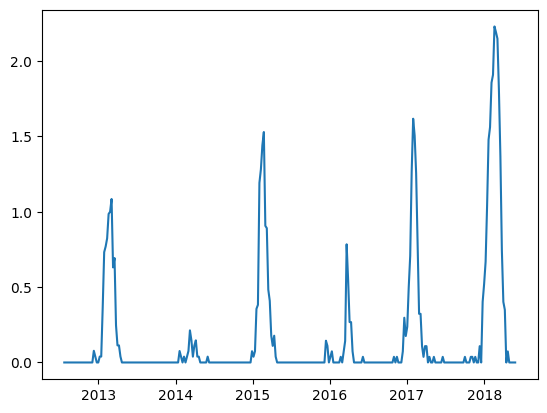

In [14]:
node = logged[logged['node'] == 204]
plt.plot(node['timestamp'], node['incidence'])

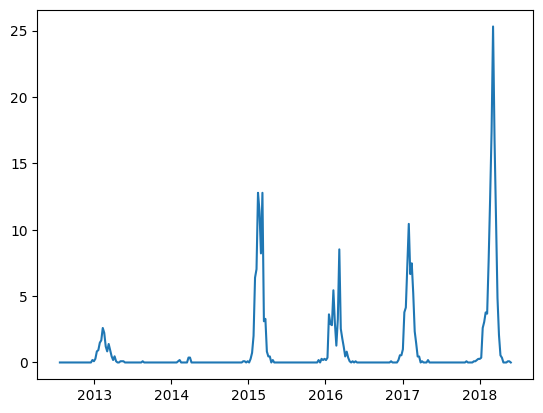

In [17]:
node = unlogged[unlogged['node'] == 391]
plt.plot(node['timestamp'], node['incidence'])

In [18]:
from src.dataloading.epidataloader import EpiDataLoader
from src.dataloading.gnndataloader import GNNDataLoader
from src.dataloading.graphconstructor import GraphConstructor

epidata = EpiDataLoader('influenza', data_env, aggr_level= '03', min_date='2012-06-01',max_date='2020-06-01')

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


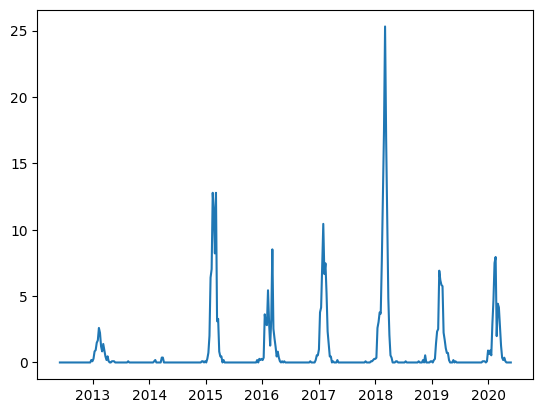

In [21]:

node = epidata.epidemiological_data[epidata.epidemiological_data['node'] == 391]
plt.plot(node['timestamp'], node['incidence'])

boolean_neighbors generated
identity_graph generated


/home/de-schrijvers/projects/germany_gnn/src/dataloading/graphconstructor.py:246: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/home/de-schrijvers/projects/germany_gnn/src/dataloading/graphconstructor.py:246: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


gravity_model_log generated


/home/de-schrijvers/projects/germany_gnn/src/dataloading/graphconstructor.py:246: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


gravity_model_top8_log generated


/home/de-schrijvers/projects/germany_gnn/src/dataloading/graphconstructor.py:246: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


edge index boolean_neighbors saved to data/graphs
edge index identity_graph saved to data/graphs
edge index gravity_model_log saved to data/graphs
edge weight gravity_model_log saved to data/graphs
edge index gravity_model_top8_log saved to data/graphs
edge weight gravity_model_top8_log saved to data/graphs


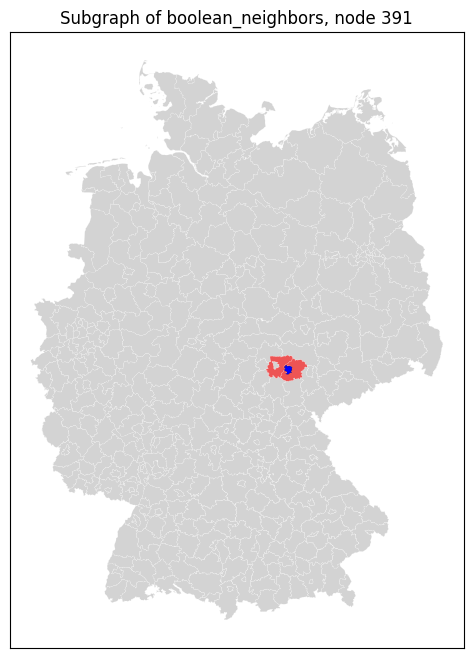

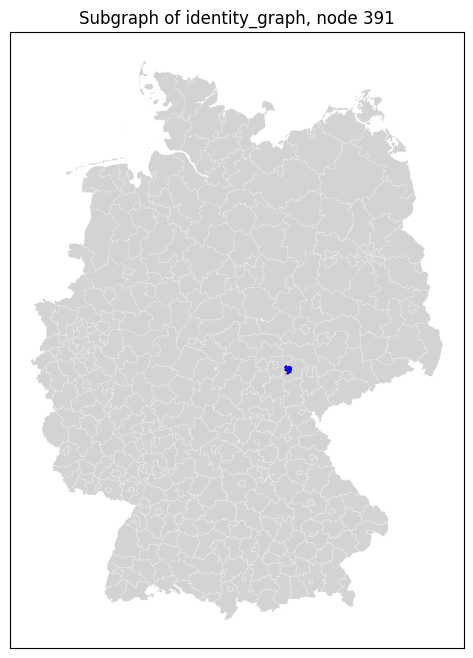

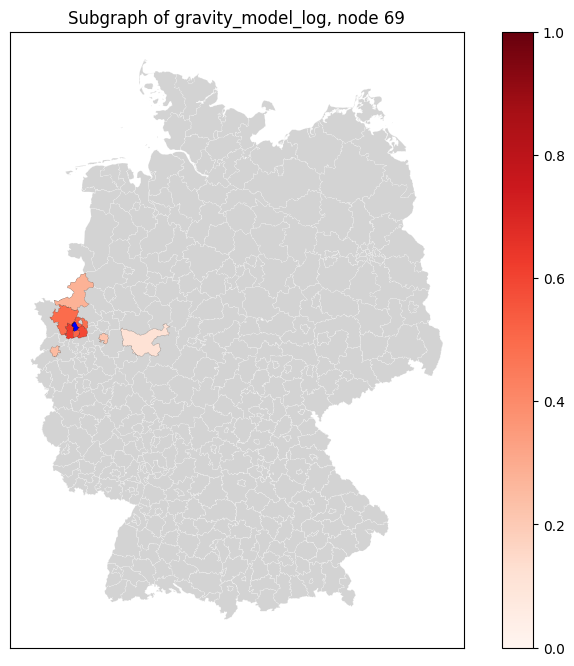

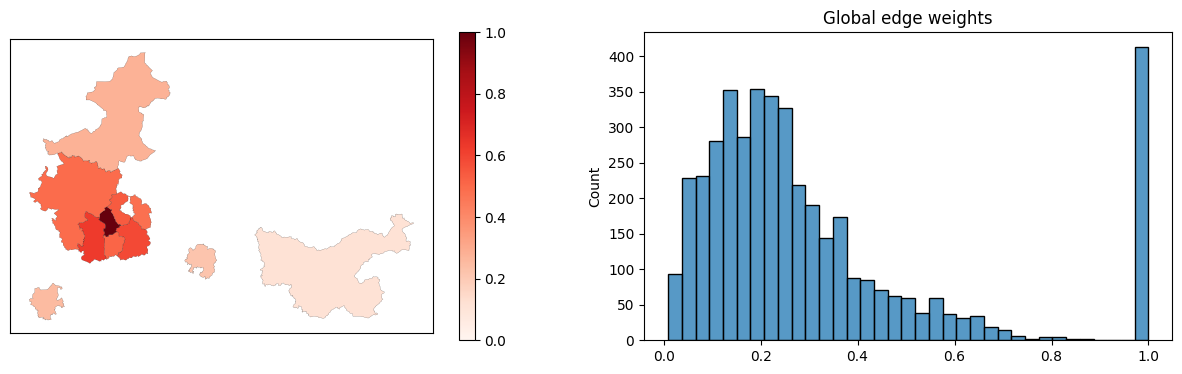

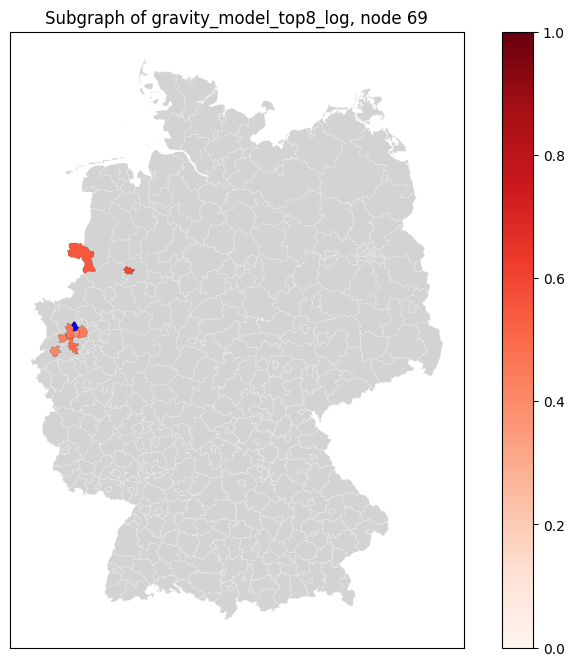

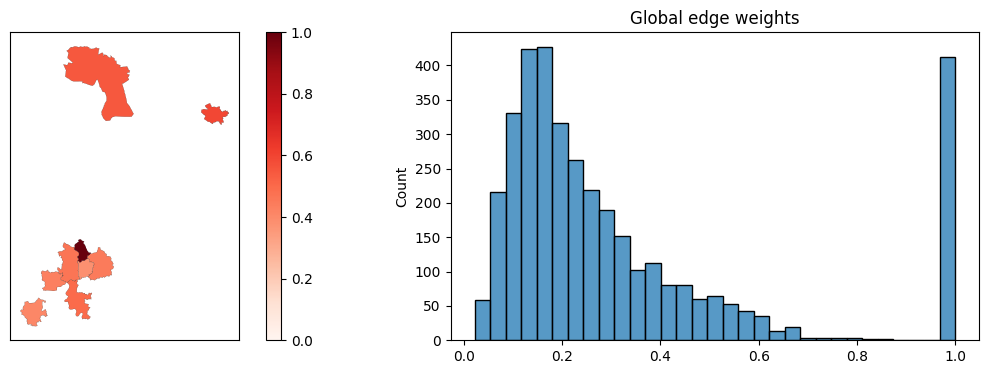

In [3]:
graphconstruction = GraphConstructor(graph_dir = 'data/graphs', population_data=epidata.population_by_node, shapes = epidata.shapedata, id_col='node')

graphconstruction.generate_graph(
    method='boolean_neighbors', 
    name_addition='',
)

graphconstruction.generate_graph(
    method='identity_graph', 
    name_addition='',
)

graphconstruction.preview_graph('boolean_neighbors',391, 1)
graphconstruction.preview_graph('identity_graph',391, 1)

graphconstruction.generate_graph(
    method='gravity_model', 
    scaling_method='log',
    max_distance = 250_000,
    alpha = 2,
    density_control = 'distance_bands',
    name_addition='',
    self_connection='1'
)
graphconstruction.preview_graph('gravity_model_log',69)

graphconstruction.generate_graph(
    method='gravity_model', 
    name_addition='top8',
    scaling_method='log',
        self_connection='1',
    max_distance=200_000,  # Reduce max distance
    alpha=2.0,
    density_control='top_k',
    k=8,  # Each node connects to max 8 others
    distance_decay_factor=1.5  # Increase distance penalty
)
graphconstruction.preview_graph('gravity_model_top8_log',69)


graphconstruction.save_graph('boolean_neighbors')
graphconstruction.save_graph('identity_graph')
graphconstruction.save_graph('gravity_model_log')
graphconstruction.save_graph('gravity_model_top8_log')